In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nTarget Names:")
print(iris.target_names)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

Target Names:
['setosa' 'versicolor' 'virginica']

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [5]:
X = df.iloc[:, :-1]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

print("Cluster Labels:")
print(clusters)

Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [8]:
df['Cluster'] = clusters

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


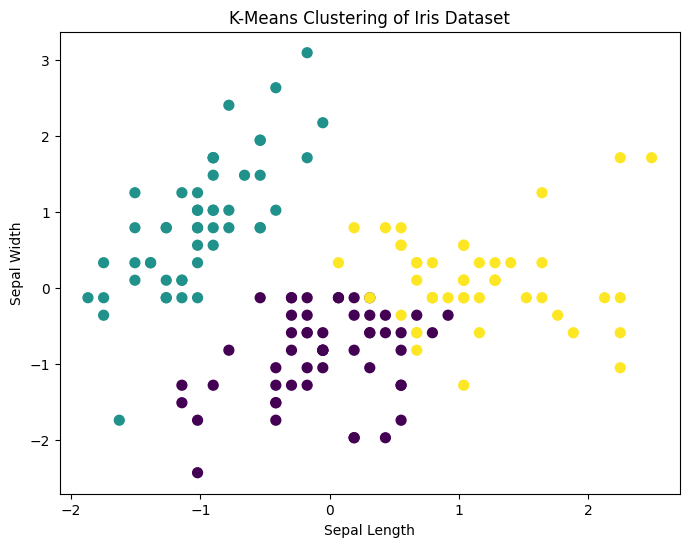

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering of Iris Dataset')

plt.show()

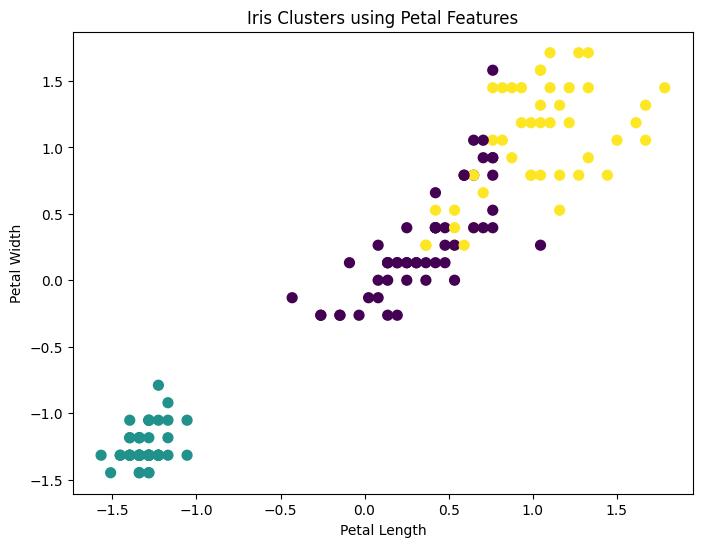

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Clusters using Petal Features')

plt.show()

In [11]:
comparison = pd.DataFrame({
    'True Label': y,
    'Predicted Cluster': clusters
})

comparison.head(20)

,True Label,Predicted Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [12]:
cm = confusion_matrix(y, clusters)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]


In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (150, 4)
PCA shape: (150, 2)


In [14]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Explained:",
      sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.72962445 0.22850762]
Total Variance Explained: 0.9581320720000166


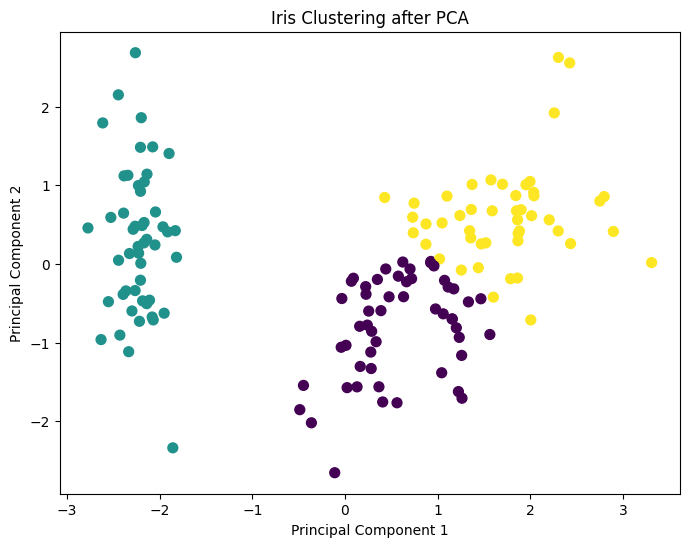

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Iris Clustering after PCA')

plt.show()

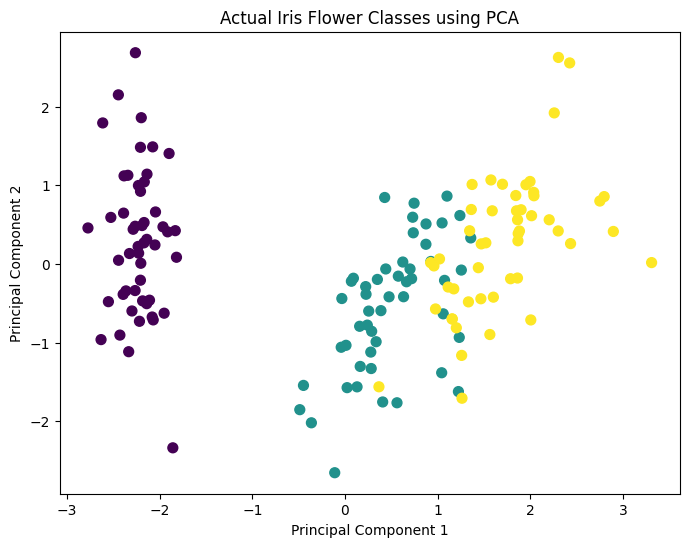

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Actual Iris Flower Classes using PCA')

plt.show()

In [17]:
print("K-Means Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nPCA Components:")
print(pca.components_)

print("\nExplained Variance:")
print(pca.explained_variance_ratio_)

K-Means Cluster Centers:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

PCA Components:
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Explained Variance:
[0.72962445 0.22850762]


K-Means clustering was successfully applied to the Iris dataset using three clusters. The flower samples were grouped based on their features without using the actual class labels. PCA was then used to reduce the four-dimensional dataset into two principal components, making the clusters easier to visualize. The clustering results show that the Iris flowers can be reasonably separated based on their measurements